In [2]:
import pandas as pd
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})
summary = summary[summary["Missing Count"] > 0].sort_values("Missing %", ascending=False)
summary

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


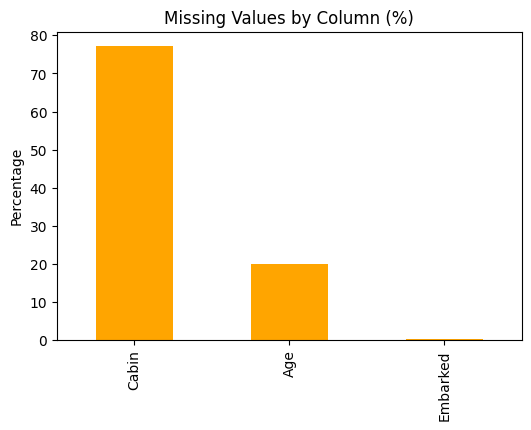

In [5]:
summary["Missing %"].plot(kind="bar", color="orange", figsize=(6,4))
plt.title("Missing Values by Column (%)")
plt.ylabel("Percentage")
plt.show()

In [6]:
summary.to_csv("missing_value_summary.csv")

## Summary of Missing Values (Task 12)

I used the Titanic dataset for this task. It has 891 rows and 12 columns. After checking nulls column by column, I found that only 3 columns have missing values: Cabin, Age and Embarked. The other 9 columns are complete.

** Findings**

- Cabin has the most missing values, 687 out of 891 (about 77%). Most passengers don't have a cabin number recorded, so this column is not very useful as it is.
- Age has 177 missing values (about 20%). This is a big gap, but since age is important for analysis, I think it can be filled later using the median.
- Embarked has only 2 missing values (about 0.22%), so it won't affect the data much.

I did not remove or fill anything in this task because the goal was only to find the missing values. Deleting rows without a proper reason could lose useful data, so I will decide how to handle them in the next steps.